# Ensemble

Autor: Bartosz Perz

In [128]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier,
)
from sklearn.metrics import accuracy_score, f1_score
from ucimlrepo import fetch_ucirepo

warnings.filterwarnings('ignore')

## Zadanie 1: Salud 2030

Na potrzeby zadania potraktuj dane jako w pełni zebrane od ankietowanych.

### Wprowadzenie

Pracujesz jako Senior Data Scientist w **Secretaría de Salud de México** – meksykańskim Ministerstwie Zdrowia. Rząd Meksyku przeznaczył ogromne fundusze, angażując Cię do pomocy w wywiązaniu się z globalnych zobowiązań wobec ONZ i WHO.

Meksyk, jako sygnatariusz Agendy 2030, kładzie szczególny nacisk na **3. Cel Zrównoważonego Rozwoju (SDG 3): Dobre zdrowie i jakość życia**. Kluczowym elementem tego celu jest **Zadanie 3.4**, które zakłada ograniczenie do 2030 roku o jedną trzecią przedwczesnej umieralności z powodu chorób niezakaźnych (NCDs) poprzez zapobieganie i leczenie.

Jak jednak spełnić to wymaganie? Bierzesz na celownik otyłość – główny czynnik ryzyka wystąpienia chorób układu krążenia, cukrzycy typu 2 i nadciśnienia, które stanowią trzon problemów zdrowotnych wymienionych w SDG 3. Twoim celem jest stworzenie modelu, który na podstawie danych ankietowych zidentyfikuje osoby wymagające interwencji profilaktycznej. Aby pozyskać zbiór danych do uczenia modeli, w wybranych przychodniach przeprowadzono badanie pilotażowe.

Musisz działać precyzyjnie, ponieważ niedokładny model pominie zagrożonych pacjentów, a model zbyt "ciężki" obliczeniowo nie będzie mógł zostać wdrożony w wiejskich przychodniach o ograniczonych zasobach. W Meksyku, gdzie wskaźniki otyłości należą do najwyższych na świecie, Twoja praca nad optymalnym modelem predykcyjnym jest bezpośrednim wkładem w walkę o wydłużenie życia obywateli i redukcję obciążenia systemu ochrony zdrowia.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych dot. otyłości (UCI ID: 544)](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition).
2. **Wyucz modele klasyfikacyjne**. Wykorzystaj bibliotekę `scikit-learn` i zbadaj:

* **Pojedyncze drzewa decyzyjne** i **regresję logistyczną** – jako bazowe modele, łatwe do interpretacji przez lekarza.
* **Bagging:** `BaggingClassifier` z płytkimi drzewami, głębokimi drzewami oraz z regresją logistyczną. Przetestuj wpływ parametrów *n_estimators*, *bootstrap* i *bootstrap_features* na wyniki.
* **Boosting:** `AdaBoost` (przetestuj na płytkich drzewach i regresji logistycznej) oraz `GradientBoosting` (oparty domyślnie na drzewach). Zbadaj relację (trade-off) między parametrami *n_estimators* i *learning_rate*.
* **Stacking & Voting:** skonstruuj kolejny komitet wg własnego uznania (dobierz parametry i modele). Połącz modele o różnej architekturze, by sprawdzić, czy zespół różnych algorytmów daje lepsze efekty niż pojedynczy "ekspert".

3. **Zwaliduj modele** pod kątem wdrożenia krajowego.

* Dobierz miary **skuteczności** modelu adekwatne do problemu.
* Zwróć uwagę na **czas predykcji**.
* Zbadaj **pewność (confidence) modelu**.

4. **Zapisz wnioski dla Ministerstwa Zdrowia.**

Przy realizacji poleceń pamiętaj o charakterze zadania. Który z modeli zarekomendowałbyś do wdrożenia? Czy dokładność modelu jest jedynym wyznacznikiem jego jakości? Czy są modele, których wdrożenie byłoby stratą zasobów publicznych?

In [129]:
df = pd.read_csv('/home/pawel/Desktop/Studia/sem2/ML/lista-5-Pewciu6/data/ObesityDataSet_raw_and_data_sinthetic.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

### EDA + preprocessing

Wiersze: 2111, braki: 0, duplikaty: 24


,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00
mean,24.31,1.70,86.59,2.42,2.69,2.01,1.01,0.66
std,6.35,0.09,26.19,0.53,0.78,0.61,0.85,0.61
min,14.00,1.45,39.00,1.00,1.00,1.00,0.00,0.00
25%,19.95,1.63,65.47,2.00,2.66,1.58,0.12,0.00
50%,22.78,1.70,83.00,2.39,3.00,2.00,1.00,0.63
75%,26.00,1.77,107.43,3.00,3.00,2.48,1.67,1.00
max,61.00,1.98,173.00,3.00,4.00,3.00,3.00,2.00


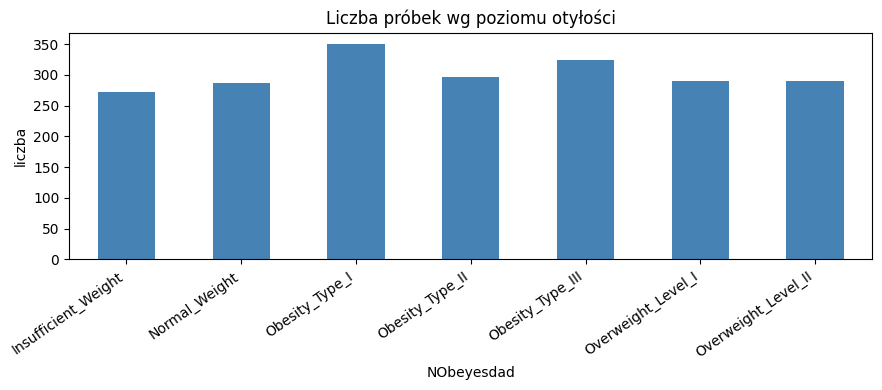

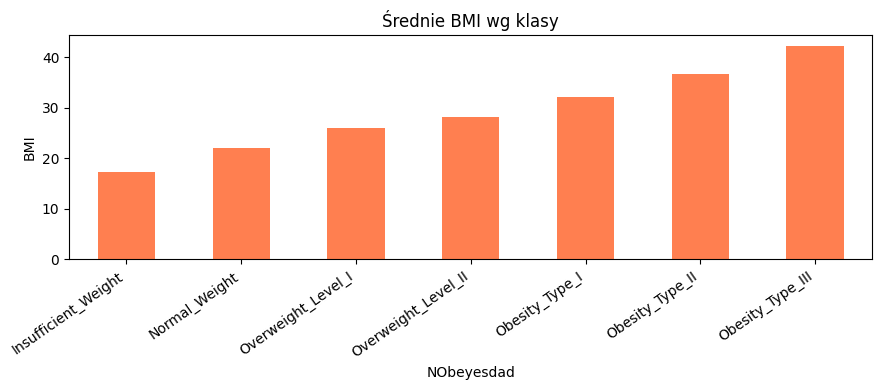

In [130]:
print(f'Wiersze: {len(df)}, braki: {df.isna().sum().sum()}, duplikaty: {df.duplicated().sum()}')

num_cols = [c for c in df.columns if df[c].dtype == 'float64']
display(df[num_cols].describe().round(2))

ax = df['NObeyesdad'].value_counts().sort_index().plot(
    kind='bar', figsize=(9, 4), title='Liczba próbek wg poziomu otyłości', color='steelblue'
)
ax.set_xlabel('NObeyesdad')
ax.set_ylabel('liczba')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

bmi = df['Weight'] / (df['Height'] ** 2)
pd.DataFrame({'NObeyesdad': df['NObeyesdad'], 'BMI': bmi}).groupby('NObeyesdad', observed=True)['BMI'].mean().sort_values().plot(
    kind='bar', figsize=(9, 4), title='Średnie BMI wg klasy', color='coral'
)
plt.xticks(rotation=35, ha='right')
plt.ylabel('BMI')
plt.tight_layout()
plt.show()

In [131]:
columns_ = df.columns 
columns_numerical = [x for x in columns_ if df[x].dtype == 'float64']
columns_categorical = [x for x in columns_ if df[x].dtype == 'str']
print(columns_numerical)
print(columns_categorical)
for x in columns_categorical:
    print(f'{x} {df[x].unique()}\n\n\n')

['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']
Gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str



family_history_with_overweight <StringArray>
['yes', 'no']
Length: 2, dtype: str



FAVC <StringArray>
['no', 'yes']
Length: 2, dtype: str



CAEC <StringArray>
['Sometimes', 'Frequently', 'Always', 'no']
Length: 4, dtype: str



SMOKE <StringArray>
['no', 'yes']
Length: 2, dtype: str



SCC <StringArray>
['no', 'yes']
Length: 2, dtype: str



CALC <StringArray>
['no', 'Sometimes', 'Frequently', 'Always']
Length: 4, dtype: str



MTRANS <StringArray>
['Public_Transportation', 'Walking', 'Automobile', 'Motorbike', 'Bike']
Length: 5, dtype: str



NObeyesdad <StringArray>
[      'Normal_Weight',  'Overweight_Level_I', 'Overweight_Level_II',
      'Obesity_Type_I', 'Insufficient_Weight',     'Obesity_Type_II',
    'Obesity_Type_III']
Length: 7, dtype: st

In [132]:
df['Gender'] = df['Gender'].map({'Male':0,'Female':1})
df['family_history_with_overweight'] = df['family_history_with_overweight'].map({'yes':1,'no':0})
df['FAVC'] = df['FAVC'].map({'yes':1,'no':0})
df['SMOKE'] = df['SMOKE'].map({'yes':1,'no':0})
df['SCC'] = df['SCC'].map({'yes':1,'no':0})
df['CALC'] = df['CALC'].map({'no':0, 'Sometimes':1, 'Frequently':2, 'Always':3})
df['MTRANS'] = df['MTRANS'].map({'Public_Transportation':0, 'Walking':1, 'Automobile':2, 'Motorbike':3, 'Bike':4})
df['CAEC'] = df['CAEC'].map({'no':0,'Sometimes':1,'Frequently':2,'Always':3})
df['NObeyesdad'] = df['NObeyesdad'].map({'Normal_Weight':0,'Overweight_Level_I':1, 'Overweight_Level_II':2,'Obesity_Type_I':3, 'Insufficient_Weight':4,'Obesity_Type_II':5,'Obesity_Type_III':6})


In [133]:
for x in columns_categorical:
    unq = df[x].unique()
    print(unq)

[1 0]
[1 0]
[0 1]
[1 2 3 0]
[0 1]
[0 1]
[0 1 2 3]
[0 1 2 3 4]
[0 1 2 3 4 5 6]


In [134]:
X = df.drop(columns=['NObeyesdad'])
y = df['NObeyesdad']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train[columns_numerical] = scaler.fit_transform(X_train[columns_numerical])
X_test[columns_numerical] = scaler.transform(X_test[columns_numerical])

### Modele klasyfikacyjne

In [135]:
results = []

def evaluate_model(model, name):
    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred = model.predict(X_test)
    pred_time = time.perf_counter() - t0

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    conf = np.mean(np.max(model.predict_proba(X_test), axis=1))

    results.append({
        'model': name,
        'accuracy': acc,
        'macro_f1': f1,
        'confidence': conf,
        'fit_time_s': fit_time,
        'predict_time_ms': pred_time * 1000,
    })
    print(f'{name:42} Acc={acc:.3f}  F1={f1:.3f}  Conf={conf:.3f}  predict={pred_time*1000:.2f} ms')
    return model

In [136]:
evaluate_model(DecisionTreeClassifier(random_state=42), 'DT (default)')
evaluate_model(DecisionTreeClassifier(max_depth=3, random_state=42), 'DT (max_depth=3)')
evaluate_model(LogisticRegression(max_iter=2000, random_state=42), 'Logistic Regression')

DT (default)                               Acc=0.937  F1=0.936  Conf=1.000  predict=1.82 ms
DT (max_depth=3)                           Acc=0.653  F1=0.639  Conf=0.650  predict=1.84 ms
Logistic Regression                        Acc=0.877  F1=0.873  Conf=0.732  predict=1.80 ms


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [137]:
shallow_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
deep_tree = DecisionTreeClassifier(random_state=42)
base_lr = LogisticRegression(max_iter=2000, random_state=42)

evaluate_model(
    BaggingClassifier(estimator=shallow_tree, n_estimators=10, random_state=42),
    'Bagging — shallow tree (n=10)',
)
evaluate_model(
    BaggingClassifier(estimator=deep_tree, n_estimators=10, random_state=42),
    'Bagging — deep tree (n=10)',
)
evaluate_model(
    BaggingClassifier(estimator=base_lr, n_estimators=10, random_state=42),
    'Bagging — logistic (n=10)',
)

print('\nBagging grid (shallow tree):')
for n_est in [5, 10, 25]:
    for bootstrap in [True, False]:
        for bootstrap_features in [True, False]:
            name = f'Bagging shallow n={n_est} boot={bootstrap} boot_feat={bootstrap_features}'
            evaluate_model(
                BaggingClassifier(
                    estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
                    n_estimators=n_est,
                    bootstrap=bootstrap,
                    bootstrap_features=bootstrap_features,
                    random_state=42,
                ),
                name,
            )

Bagging — shallow tree (n=10)              Acc=0.666  F1=0.631  Conf=0.636  predict=3.61 ms
Bagging — deep tree (n=10)                 Acc=0.965  F1=0.964  Conf=0.932  predict=2.86 ms
Bagging — logistic (n=10)                  Acc=0.863  F1=0.859  Conf=0.733  predict=5.77 ms

Bagging grid (shallow tree):
Bagging shallow n=5 boot=True boot_feat=True Acc=0.681  F1=0.659  Conf=0.626  predict=3.44 ms
Bagging shallow n=5 boot=True boot_feat=False Acc=0.669  F1=0.635  Conf=0.635  predict=2.52 ms
Bagging shallow n=5 boot=False boot_feat=True Acc=0.692  F1=0.676  Conf=0.618  predict=2.38 ms
Bagging shallow n=5 boot=False boot_feat=False Acc=0.653  F1=0.639  Conf=0.650  predict=2.04 ms
Bagging shallow n=10 boot=True boot_feat=True Acc=0.726  F1=0.711  Conf=0.560  predict=2.78 ms
Bagging shallow n=10 boot=True boot_feat=False Acc=0.666  F1=0.631  Conf=0.636  predict=3.20 ms
Bagging shallow n=10 boot=False boot_feat=True Acc=0.719  F1=0.701  Conf=0.559  predict=1.60 ms
Bagging shallow n=10 boot=F

In [138]:
evaluate_model(
    AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
        n_estimators=50,
        learning_rate=1.0,
        random_state=42,
    ),
    'AdaBoost — shallow tree',
)
evaluate_model(
    AdaBoostClassifier(
        estimator=LogisticRegression(max_iter=2000, random_state=42),
        n_estimators=50,
        learning_rate=0.5,
        random_state=42,
    ),
    'AdaBoost — logistic',
)

print('\nGradientBoosting: n_estimators vs learning_rate')
for n_est, lr in [(50, 0.1), (100, 0.1), (50, 0.05), (100, 0.05)]:
    evaluate_model(
        GradientBoostingClassifier(
            n_estimators=n_est,
            learning_rate=lr,
            random_state=42,
        ),
        f'GBC n={n_est} lr={lr}',
    )

AdaBoost — shallow tree                    Acc=0.942  F1=0.941  Conf=0.151  predict=5.99 ms
AdaBoost — logistic                        Acc=0.653  F1=0.653  Conf=0.149  predict=9.89 ms

GradientBoosting: n_estimators vs learning_rate
GBC n=50 lr=0.1                            Acc=0.945  F1=0.944  Conf=0.891  predict=6.26 ms
GBC n=100 lr=0.1                           Acc=0.954  F1=0.954  Conf=0.952  predict=7.50 ms
GBC n=50 lr=0.05                           Acc=0.934  F1=0.933  Conf=0.779  predict=4.58 ms
GBC n=100 lr=0.05                          Acc=0.938  F1=0.938  Conf=0.889  predict=8.19 ms


In [139]:
voting = VotingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier(max_depth=3, random_state=42)),
        ('lr', LogisticRegression(max_iter=2000, random_state=42)),
        ('bag', BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
            n_estimators=10,
            random_state=42,
        )),
    ],
    voting='soft',
)
evaluate_model(voting, 'VotingClassifier (soft)')

stacking = StackingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier(max_depth=3, random_state=42)),
        ('lr', LogisticRegression(max_iter=2000, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, random_state=42)),
    ],
    final_estimator=LogisticRegression(max_iter=2000, random_state=42),
    cv=5,
)
evaluate_model(stacking, 'StackingClassifier')

VotingClassifier (soft)                    Acc=0.814  F1=0.808  Conf=0.645  predict=5.88 ms
StackingClassifier                         Acc=0.956  F1=0.955  Conf=0.934  predict=7.50 ms


,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('dt', ...), ('lr', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum numbe

In [140]:
results_df = (
    pd.DataFrame(results)
    .sort_values('macro_f1', ascending=False)
    .round({'accuracy': 3, 'macro_f1': 3, 'confidence': 3, 'fit_time_s': 3, 'predict_time_ms': 2})
)
display(results_df)

best = results_df.iloc[0]
print(f"\nNajlepszy macro-F1: {best['model']} (F1={best['macro_f1']:.3f}, Acc={best['accuracy']:.3f})")

,model,accuracy,macro_f1,confidence,fit_time_s,predict_time_ms
4,Bagging — deep tree (n=10),0.965,0.964,0.932,0.057,2.86
25,StackingClassifier,0.956,0.955,0.934,4.985,7.50
21,GBC n=100 lr=0.1,0.954,0.954,0.952,1.820,7.50
20,GBC n=50 lr=0.1,0.945,0.944,0.891,0.965,6.26
18,AdaBoost — shallow tree,0.942,0.941,0.151,0.314,5.99
23,GBC n=100 lr=0.05,0.938,0.938,0.889,1.859,8.19
0,DT (default),0.937,0.936,1.000,0.011,1.82
22,GBC n=50 lr=0.05,0.934,0.933,0.779,0.851,4.58
2,Logistic Regression,0.877,0.873,0.732,0.049,1.80
5,Bagging — logistic (n=10),0.863,0.859,0.733,0.665,5.77



Najlepszy macro-F1: Bagging — deep tree (n=10) (F1=0.964, Acc=0.965)


## Zadanie 2: Grzybobranie


### Wprowadzenie

Mieszkasz w "Warszawce". Ostatnio całe miasto opanował nowy trend – grzybobranie! Czy wiedziałeś, że grzybów nie trzeba kupować w sklepie? Rosną w lesie, zupełnie za darmo i E-KO-LO-GICZ-NIE.

Postanawiasz wybrać się do "mało znanego" miejsca – lasu pod Konstancinem-Jeziorną. Niestety, na miejscu okazuje się, że o grzybach nie masz zielonego pojęcia, a odróżnienie borowika od muchomora stanowi dla Ciebie ogromne wyzwanie. Już masz się poddać, ale nagle słyszysz za sobą podniesiony głos:

– Radziu, nie mów do mnie teraz!

Obracasz się i widzisz miło wyglądającą rodzinkę.

<img src="img.jpg" width="400" height="400" />

(Źródło: <a href="https://www.instagram.com/p/COLCA3RHoni/">instagram m_rozenek</a>)

Skądś ich kojarzysz (może z *morning matcha rave*?), ale nie to jest teraz najważniejsze. Widzisz, że próbują rozszyfrować **ZAAWANSOWANY ATLAS GRZYBÓW**. Postanawiasz dołączyć do zadania, ale szybko okazuje się, że rozumiesz z niego tyle co nic. Zamiast zdjęć i opisów, atlas zawiera wyłącznie tabele przedstawiające cechy grzybów. Sprawdzanie całej tabeli w poszukiwaniu odpowiedniego dopasowania do zaobserwowanych parametrów okazu od razu wydaje Ci się marnowaniem czasu. Wykorzystujesz więc wiedzę nabytą na zajęciach ze Sztucznej Inteligencji i postanawiasz stworzyć model uczenia maszynowego klasyfikujący grzyby.

Pamiętaj – błąd algorytmu oznacza poważne zatrucie. Chociaż masz dostęp do potężnych narzędzi, bateria w Twoim telefonie jest na wyczerpaniu, a każda sekunda pracy procesora jest na wagę złota. Musisz zdecydować, jaki model będzie adekwatny do zadania – na tyle precyzyjny, by przeżyć, a zarazem wystarczająco "lekki", by zadziałał w lesie.

### Polecenia:

1. **Wykonaj analizę eksploracyjną (EDA)** [zbioru danych o grzybach (UCI ID: 73)](https://archive.ics.uci.edu/dataset/73/mushroom).
2. Według własnego uznania **wybierz modele** i **wyucz** je. Wykorzystaj zdobytą dotychczas wiedzę. Przynajmniej jednym z testowanych modeli powinien być model zespołowy (ensemble).
3. **Zwaliduj wyuczone modele**. Pamiętaj, że pomyłka może skończyć się zatruciem, więc warto byłoby móc zinterpretować i zrozumieć decyzje modelu.
4. **Zapisz wnioski**.

Przy realizacji poleceń pamiętaj o specyficznym charakterze i ograniczeniach zadania.

In [141]:
mushroom = fetch_ucirepo(id=73)
df2 = pd.concat([mushroom.data.features, mushroom.data.targets], axis=1)
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   cap-shape                 8124 non-null   str  
 1   cap-surface               8124 non-null   str  
 2   cap-color                 8124 non-null   str  
 3   bruises                   8124 non-null   str  
 4   odor                      8124 non-null   str  
 5   gill-attachment           8124 non-null   str  
 6   gill-spacing              8124 non-null   str  
 7   gill-size                 8124 non-null   str  
 8   gill-color                8124 non-null   str  
 9   stalk-shape               8124 non-null   str  
 10  stalk-root                5644 non-null   str  
 11  stalk-surface-above-ring  8124 non-null   str  
 12  stalk-surface-below-ring  8124 non-null   str  
 13  stalk-color-above-ring    8124 non-null   str  
 14  stalk-color-below-ring    8124 non-null   str  
 15

### EDA (podstawowa) — grzyby

Przegląd przed modelem: braki w `stalk-root`, balans jadalne (`e`) vs trujące (`p`).

Wiersze: 8124, braki stalk-root: 2480
poisonous
e    4208
p    3916
Name: count, dtype: int64


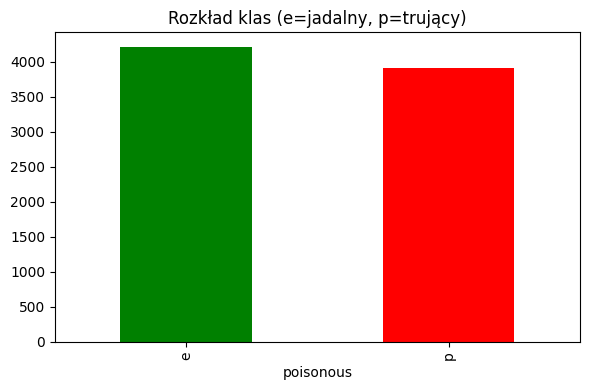

In [142]:
print(f'Wiersze: {len(df2)}, braki stalk-root: {df2["stalk-root"].isna().sum()}')
print(df2['poisonous'].value_counts())

ax = df2['poisonous'].value_counts().plot(
    kind='bar', figsize=(6, 4), title='Rozkład klas (e=jadalny, p=trujący)', color=['green', 'red']
)
ax.set_xlabel('poisonous')
plt.tight_layout()
plt.show()

In [143]:
from sklearn.preprocessing import OrdinalEncoder

df2 = df2.dropna(subset=['stalk-root']).reset_index(drop=True)
target_col2 = 'poisonous'
feature_cols2 = [c for c in df2.columns if c != target_col2]

oe2 = OrdinalEncoder()
df2[feature_cols2] = oe2.fit_transform(df2[feature_cols2]).astype(int)
df2[target_col2] = df2[target_col2].map({'e': 0, 'p': 1})  # 1 = trujący

print(f'Po dropna: {len(df2)} wierszy, cechy: {len(feature_cols2)}')
print(df2[target_col2].value_counts())

Po dropna: 5644 wierszy, cechy: 22
poisonous
0    3488
1    2156
Name: count, dtype: int64


In [144]:
X2 = df2[feature_cols2]
y2 = df2[target_col2]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.3, random_state=42, stratify=y2
)
print(X_train2.shape, X_test2.shape)

(3950, 22) (1694, 22)


### Modele klasyfikacyjne — grzyby

Ta sama procedura co w zadaniu 1 (bazowe, bagging, boosting, voting, stacking). Cel binarny: wykryć trujące (`p`=1).

In [145]:
results2 = []

def evaluate_model2(model, name):
    t0 = time.perf_counter()
    model.fit(X_train2, y_train2)
    fit_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred = model.predict(X_test2)
    pred_time = time.perf_counter() - t0

    acc = accuracy_score(y_test2, y_pred)
    f1 = f1_score(y_test2, y_pred, average='macro')
    conf = np.mean(np.max(model.predict_proba(X_test2), axis=1))

    results2.append({
        'model': name,
        'accuracy': acc,
        'macro_f1': f1,
        'confidence': conf,
        'fit_time_s': fit_time,
        'predict_time_ms': pred_time * 1000,
    })
    print(f'{name:42} Acc={acc:.3f}  F1={f1:.3f}  Conf={conf:.3f}  predict={pred_time*1000:.2f} ms')
    return model

In [146]:
evaluate_model2(DecisionTreeClassifier(random_state=42), 'DT (default)')
evaluate_model2(DecisionTreeClassifier(max_depth=3, random_state=42), 'DT (max_depth=3)')
evaluate_model2(LogisticRegression(max_iter=2000, random_state=42), 'Logistic Regression')

DT (default)                               Acc=1.000  F1=1.000  Conf=1.000  predict=3.13 ms
DT (max_depth=3)                           Acc=0.967  F1=0.966  Conf=0.967  predict=3.42 ms
Logistic Regression                        Acc=0.964  F1=0.962  Conf=0.939  predict=1.67 ms


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [147]:
shallow_tree2 = DecisionTreeClassifier(max_depth=3, random_state=42)
deep_tree2 = DecisionTreeClassifier(random_state=42)
base_lr2 = LogisticRegression(max_iter=2000, random_state=42)

evaluate_model2(
    BaggingClassifier(estimator=shallow_tree2, n_estimators=10, random_state=42),
    'Bagging — shallow tree (n=10)',
)
evaluate_model2(
    BaggingClassifier(estimator=deep_tree2, n_estimators=10, random_state=42),
    'Bagging — deep tree (n=10)',
)
evaluate_model2(
    BaggingClassifier(estimator=base_lr2, n_estimators=10, random_state=42),
    'Bagging — logistic (n=10)',
)

print('\nBagging grid (shallow tree):')
for n_est in [5, 10, 25]:
    for bootstrap in [True, False]:
        for bootstrap_features in [True, False]:
            name = f'Bagging shallow n={n_est} boot={bootstrap} boot_feat={bootstrap_features}'
            evaluate_model2(
                BaggingClassifier(
                    estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
                    n_estimators=n_est,
                    bootstrap=bootstrap,
                    bootstrap_features=bootstrap_features,
                    random_state=42,
                ),
                name,
            )

Bagging — shallow tree (n=10)              Acc=0.967  F1=0.966  Conf=0.953  predict=4.83 ms
Bagging — deep tree (n=10)                 Acc=1.000  F1=1.000  Conf=1.000  predict=3.94 ms
Bagging — logistic (n=10)                  Acc=0.963  F1=0.960  Conf=0.939  predict=4.95 ms

Bagging grid (shallow tree):
Bagging shallow n=5 boot=True boot_feat=True Acc=0.955  F1=0.951  Conf=0.945  predict=2.45 ms
Bagging shallow n=5 boot=True boot_feat=False Acc=0.970  F1=0.969  Conf=0.946  predict=2.33 ms
Bagging shallow n=5 boot=False boot_feat=True Acc=0.967  F1=0.966  Conf=0.946  predict=2.75 ms
Bagging shallow n=5 boot=False boot_feat=False Acc=0.967  F1=0.966  Conf=0.967  predict=3.20 ms
Bagging shallow n=10 boot=True boot_feat=True Acc=0.982  F1=0.981  Conf=0.938  predict=3.99 ms
Bagging shallow n=10 boot=True boot_feat=False Acc=0.967  F1=0.966  Conf=0.953  predict=4.11 ms
Bagging shallow n=10 boot=False boot_feat=True Acc=0.991  F1=0.991  Conf=0.936  predict=4.39 ms
Bagging shallow n=10 boot=F

In [148]:
evaluate_model2(
    AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
        n_estimators=50,
        learning_rate=1.0,
        random_state=42,
    ),
    'AdaBoost — shallow tree',
)
evaluate_model2(
    AdaBoostClassifier(
        estimator=LogisticRegression(max_iter=2000, random_state=42),
        n_estimators=50,
        learning_rate=0.5,
        random_state=42,
    ),
    'AdaBoost — logistic',
)

print('\nGradientBoosting: n_estimators vs learning_rate')
for n_est, lr in [(50, 0.1), (100, 0.1), (50, 0.05), (100, 0.05)]:
    evaluate_model2(
        GradientBoostingClassifier(
            n_estimators=n_est,
            learning_rate=lr,
            random_state=42,
        ),
        f'GBC n={n_est} lr={lr}',
    )

AdaBoost — shallow tree                    Acc=1.000  F1=1.000  Conf=0.805  predict=8.54 ms
AdaBoost — logistic                        Acc=0.916  F1=0.911  Conf=0.722  predict=2.89 ms

GradientBoosting: n_estimators vs learning_rate
GBC n=50 lr=0.1                            Acc=1.000  F1=1.000  Conf=0.991  predict=1.92 ms
GBC n=100 lr=0.1                           Acc=1.000  F1=1.000  Conf=1.000  predict=5.20 ms
GBC n=50 lr=0.05                           Acc=0.990  F1=0.989  Conf=0.934  predict=2.16 ms
GBC n=100 lr=0.05                          Acc=1.000  F1=1.000  Conf=0.989  predict=3.04 ms


In [149]:
voting2 = VotingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier(max_depth=3, random_state=42)),
        ('lr', LogisticRegression(max_iter=2000, random_state=42)),
        ('bag', BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=3, random_state=42),
            n_estimators=10,
            random_state=42,
        )),
    ],
    voting='soft',
)
evaluate_model2(voting2, 'VotingClassifier (soft)')

stacking2 = StackingClassifier(
    estimators=[
        ('dt', DecisionTreeClassifier(max_depth=3, random_state=42)),
        ('lr', LogisticRegression(max_iter=2000, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, random_state=42)),
    ],
    final_estimator=LogisticRegression(max_iter=2000, random_state=42),
    cv=5,
)
evaluate_model2(stacking2, 'StackingClassifier')

VotingClassifier (soft)                    Acc=0.976  F1=0.975  Conf=0.946  predict=6.29 ms
StackingClassifier                         Acc=1.000  F1=1.000  Conf=0.996  predict=6.08 ms


,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('dt', ...), ('lr', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum numbe

In [150]:
results_df2 = (
    pd.DataFrame(results2)
    .sort_values('macro_f1', ascending=False)
    .round({'accuracy': 3, 'macro_f1': 3, 'confidence': 3, 'fit_time_s': 3, 'predict_time_ms': 2})
)
display(results_df2)

best2 = results_df2.iloc[0]
print(f"\nNajlepszy macro-F1: {best2['model']} (F1={best2['macro_f1']:.3f}, Acc={best2['accuracy']:.3f})")

,model,accuracy,macro_f1,confidence,fit_time_s,predict_time_ms
0,DT (default),1.000,1.000,1.000,0.013,3.13
4,Bagging — deep tree (n=10),1.000,1.000,1.000,0.035,3.94
25,StackingClassifier,1.000,1.000,0.996,1.201,6.08
20,GBC n=50 lr=0.1,1.000,1.000,0.991,0.136,1.92
21,GBC n=100 lr=0.1,1.000,1.000,1.000,0.337,5.20
18,AdaBoost — shallow tree,1.000,1.000,0.805,0.242,8.54
23,GBC n=100 lr=0.05,1.000,1.000,0.989,0.371,3.04
12,Bagging shallow n=10 boot=False boot_feat=True,0.991,0.991,0.936,0.043,4.39
16,Bagging shallow n=25 boot=False boot_feat=True,0.991,0.991,0.937,0.195,9.04
22,GBC n=50 lr=0.05,0.990,0.989,0.934,0.128,2.16



Najlepszy macro-F1: DT (default) (F1=1.000, Acc=1.000)
